In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report)

In [2]:
df = pd.read_csv('SMSSpamCollection', sep='\t', header=None)
df.columns = ['label', 'message']
df['label'] = df['label'].map({'spam': 1, 'ham': 0})

In [3]:
# Vectorise ─────────────────────────────────────
vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = vectorizer.fit_transform(df['message'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [4]:
# Train and Evaluate ────────────────────────────
classifiers = {
    'Naive Bayes': MultinomialNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}
results = {}
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    results[name] = {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred)
    }
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['Ham','Spam']))


=== Naive Bayes ===
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.88      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115


=== Decision Tree ===
              precision    recall  f1-score   support

         Ham       0.96      0.99      0.97       966
        Spam       0.95      0.70      0.81       149

    accuracy                           0.96      1115
   macro avg       0.95      0.85      0.89      1115
weighted avg       0.96      0.96      0.95      1115


=== Random Forest ===
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.86      0.92       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      1115
weighte

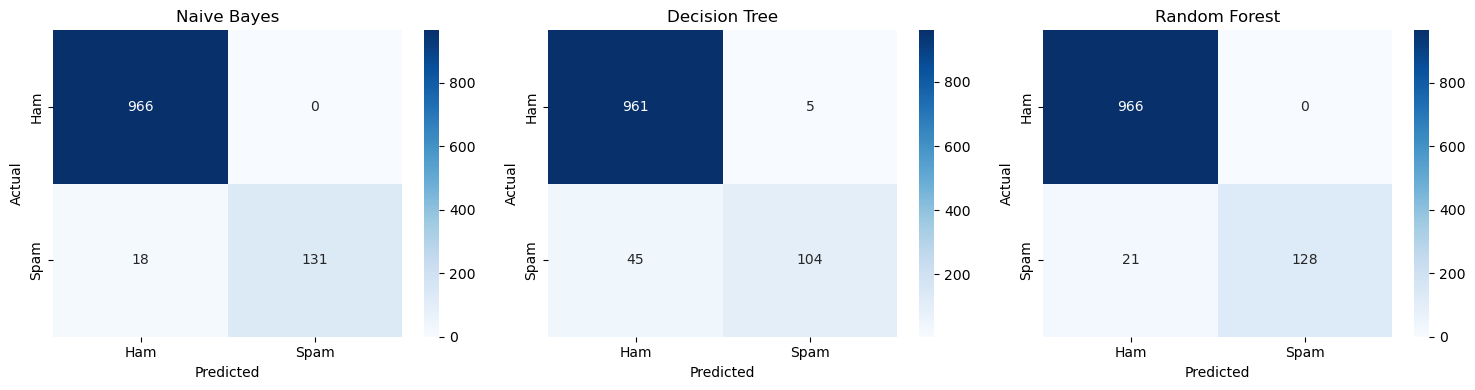

In [5]:
# Confusion Matrix Plot ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, clf) in zip(axes, classifiers.items()):
    cm = confusion_matrix(y_test, clf.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Ham','Spam'], yticklabels=['Ham','Spam'])
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.savefig('confusion_matrices.png', dpi=150)